# Direct Comparison Questions Visualization

Visualize the 5 direct comparison questions (1–7 scale: 1=Graph, 7=List) as grouped bar charts.
One chart per question; groups = user studies. Bars colored by Likert value (green=graph, purple=list).

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

sns.set_theme(style='dark', palette='muted', font_scale=1.5)

BASE = Path('.').resolve()
if (BASE / 'diversity').exists():
    pass  # cwd is user_study_results
elif (BASE / 'user_study_results' / 'diversity').exists():
    BASE = BASE / 'user_study_results'
else:
    BASE = BASE.parent

# Colors: graph=#7ab89a (green), list=#8b5a5a (purple/maroon)
GRAPH_COLOR = (122/255, 184/255, 154/255)
LIST_COLOR = (139/255, 90/255, 90/255)

def value_to_color(v):
    """Map 1-7 to gradient from graph (green) to list (purple)."""
    t = (float(v) - 1) / 6  # 0 when v=1, 1 when v=7
    return tuple(GRAPH_COLOR[i] * (1 - t) + LIST_COLOR[i] * t for i in range(3))

QUESTIONS = [
    "Which interface made the task easier overall?",
    "Which interface felt more overwhelming to use?",
    "Which interface better supported understanding the range and distribution of outputs?",
    "Which interface made you feel more confident in your answers?",
    "Overall, which interface do you prefer?",
]

STUDIES = ['Diversity', 'Single distribution', 'Compare distributions']

In [2]:
# Partial strings to uniquely match comparison questions (avoid Likert columns)
QUESTION_KEYS = {
    "Which interface made the task easier overall?": "made the task easier",
    "Which interface felt more overwhelming to use?": "felt more overwhelming",
    "Which interface better supported understanding the range and distribution of outputs?": "range and distribution",
    "Which interface made you feel more confident in your answers?": "feel more confident in your answers",
    "Overall, which interface do you prefer?": "Overall, which interface",
}

def find_col(df, partial):
    """Find column containing partial string."""
    for c in df.columns:
        if partial.lower() in str(c).lower():
            return c
    return None

def load_diversity_comparisons():
    df = pd.read_csv(BASE / 'diversity' / 'user_study_logging - diversity.csv')
    out = {}
    for q in QUESTIONS:
        col = find_col(df, QUESTION_KEYS[q])
        if col:
            vals = pd.to_numeric(df[col], errors='coerce')
            out[q] = vals[(vals >= 1) & (vals <= 7)].dropna()
        else:
            out[q] = pd.Series(dtype=float)
    return out

def load_compare_comparisons():
    df = pd.read_csv(BASE / 'compare_distributions' / 'user_study_logging - comparing comparisons.csv')
    out = {}
    for q in QUESTIONS:
        col = find_col(df, QUESTION_KEYS[q])
        if col:
            vals = pd.to_numeric(df[col], errors='coerce')
            out[q] = vals[(vals >= 1) & (vals <= 7)].dropna()
        else:
            out[q] = pd.Series(dtype=float)
    return out

def load_single_comparisons():
    df = pd.read_csv(BASE / 'single_distribution' / 'user_study_logging - Comparison.csv')
    # Columns 1-5 are the comparison questions (col 0 is Timestamp)
    col_names = list(df.columns[1:6])
    out = {}
    for i, q in enumerate(QUESTIONS):
        if i < len(col_names):
            vals = pd.to_numeric(df[col_names[i]], errors='coerce')
            out[q] = vals[(vals >= 1) & (vals <= 7)].dropna()
        else:
            out[q] = pd.Series(dtype=float)
    return out

div = load_diversity_comparisons()
comp = load_compare_comparisons()
single = load_single_comparisons()

# Build counts: for each question, {study: {1: count, 2: count, ...}}
data = {}
for q in QUESTIONS:
    data[q] = {
        'Diversity': div[q].value_counts().reindex(range(1, 8), fill_value=0).to_dict(),
        'Compare distributions': comp[q].value_counts().reindex(range(1, 8), fill_value=0).to_dict(),
        'Single distribution': single[q].value_counts().reindex(range(1, 8), fill_value=0).to_dict(),
    }
print('Data loaded. Sample counts for first question:')
print(data[QUESTIONS[0]])

Data loaded. Sample counts for first question:
{'Diversity': {1: 20, 2: 7, 3: 1, 4: 0, 5: 1, 6: 6, 7: 3}, 'Compare distributions': {1: 8, 2: 3, 3: 4, 4: 5, 5: 6, 6: 11, 7: 5}, 'Single distribution': {1: 10, 2: 4, 3: 2, 4: 1, 5: 9, 6: 7, 7: 12}}


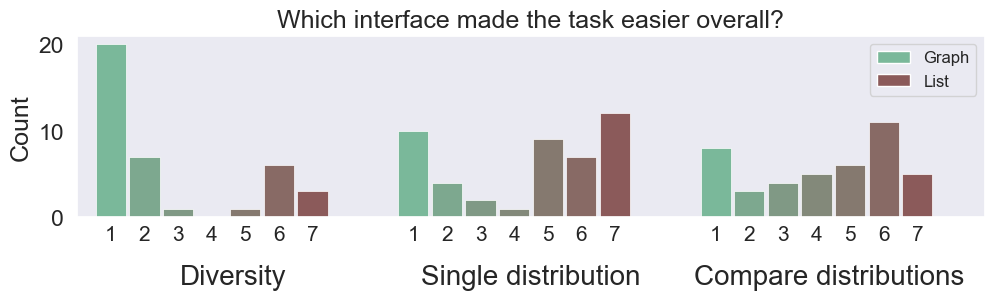

Saved direct_comparison_easier_overall.png


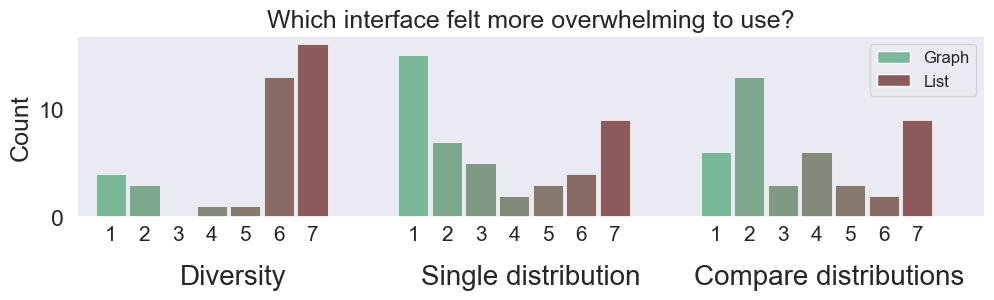

Saved direct_comparison_more_overwhelming.png


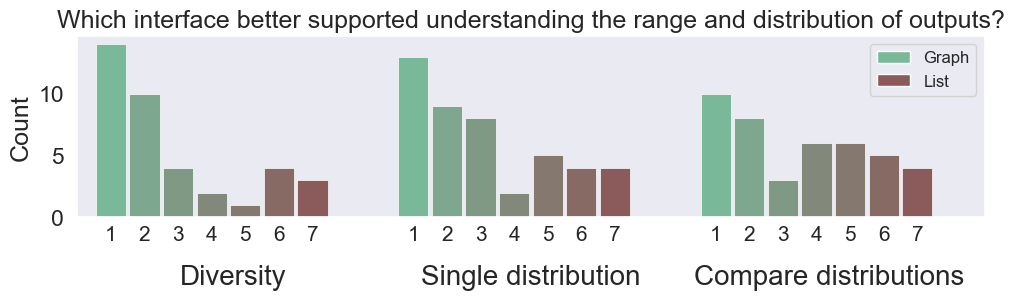

Saved direct_comparison_range_and_distribution.png


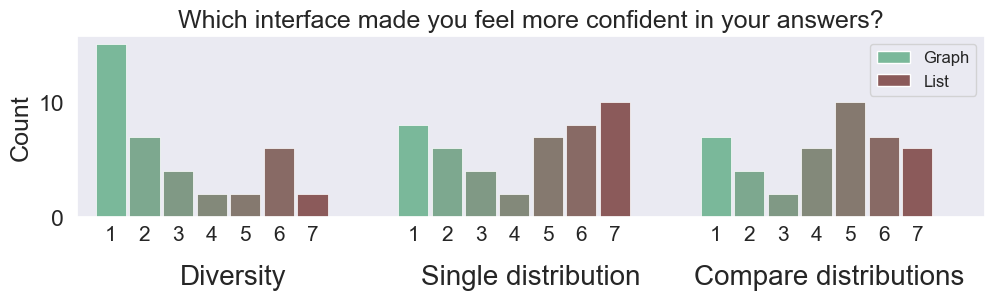

Saved direct_comparison_confident_in_answers.png


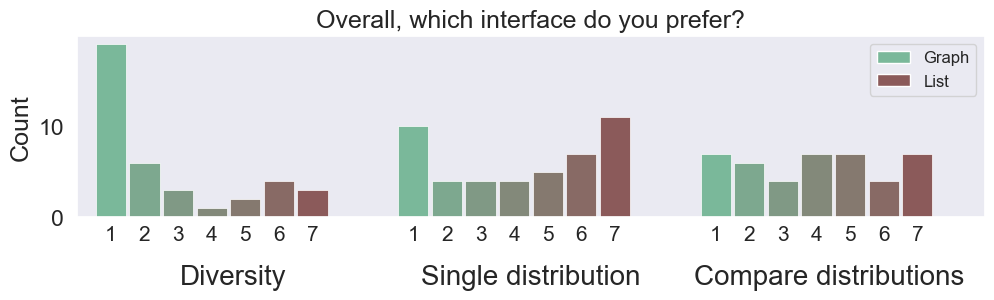

Saved direct_comparison_overall_preference.png


In [32]:
def short_label(q):
    if 'easier' in q.lower(): return 'Easier overall'
    if 'overwhelming' in q.lower(): return 'More overwhelming'
    if 'range' in q.lower(): return 'Range and distribution'
    if 'confident' in q.lower(): return 'Confident in answers'
    if 'prefer' in q.lower(): return 'Overall preference'
    return q[:40]

# Layout: 3 histograms side by side with gaps between (Diversity | gap | Compare | gap | Single)
# Each group: 7 bars (1-7); GROUP_WIDTH includes gap after each group
BARS_SPAN = 7  # bar centers at base+0.5 .. base+6.5
GROUP_WIDTH = 9   # 7 bars + 2 units gap before next group
BAR_WIDTH = 0.9
GROUP_CENTERS = [GROUP_WIDTH * i + 3.5 for i in range(3)]  # center of each group
# SCALE_LABELS = ['graph', '2', '3', '4', '5', '6', 'list']
SCALE_LABELS = [1, 2, 3, 4, 5, 6, 7]

out_dir = BASE.parent / 'latex' / 'figures'
out_dir.mkdir(parents=True, exist_ok=True)

from matplotlib.patches import Patch

for q in QUESTIONS:
    fig, ax = plt.subplots(figsize=(10, 2.9))
    study_data = data[q]
    
    for study_idx, study in enumerate(STUDIES):
        base_x = study_idx * GROUP_WIDTH
        for v in range(1, 8):
            x = base_x + v - 0.5
            count = study_data[study].get(v, 0)
            ax.bar(x, count, BAR_WIDTH, color=value_to_color(v), edgecolor='white', linewidth=0.5)
    
    # Scale labels (graph, 2, 3, 4, 5, 6, list) under each group
    tick_positions = []
    for i in range(3):
        base = i * GROUP_WIDTH
        for v in range(1, 8):
            tick_positions.append(base + v - 0.5)
    ax.set_xticks(tick_positions)
    ax.set_xticklabels(SCALE_LABELS * 3, fontsize=15)
    ax.tick_params(axis='x', pad=0)  # x-axis labels close to axis
    
    # Study names below x-axis labels - use figure coords for reliable placement
    plt.tight_layout()
    fig.subplots_adjust(bottom=0.28)  # reserve bottom space for study labels
    bbox = ax.get_position()
    x_min, x_max = ax.get_xlim()
    for i, study in enumerate(STUDIES):
        x_frac = (GROUP_CENTERS[i] - x_min) / (x_max - x_min)
        x_fig = bbox.x0 + x_frac * bbox.width
        fig.text(x_fig, 0.05, study, ha='center', fontsize=20)
    
    ax.set_ylabel('Count')
    ax.set_title(q)
    ax.set_ylim(bottom=0)
    ax.set_xlim(-0.5, GROUP_WIDTH * 3 - 0.5)
    
    # Simple legend: green=graph, purple=list
    ax.legend(handles=[
        Patch(facecolor=GRAPH_COLOR, label='Graph'),
        Patch(facecolor=LIST_COLOR, label='List'),
    ], loc='upper right', fontsize=12)
    
    fname = short_label(q).lower().replace(' ', '_').replace('(', '').replace(')', '') + '.png'
    out_path = out_dir / f'direct_comparison_{fname}'
    plt.savefig(out_path, dpi=150, bbox_inches='tight')
    plt.show()
    print(f'Saved {out_path.name}')